Step 1: Loading Data (7 Lakh rows)...
Step 2: Defining the Target...
Step 3: Implementing the Temporal Firewall (First 10 Events)...
Step 4: BEHAVIORAL DNA FEATURE ENGINEERING (Markov Sequences)...

Step 5: Training the Sequence-Aware XGBoost...

Step 6: Final Evaluation & Visualization...

--- DNA MODEL PERFORMANCE (Threshold = 0.46) ---
Accuracy:  0.965
Precision: 0.851
Recall:    0.894
F1-Score:  0.872
F2-Score:  0.885
AUC-ROC:   0.983

Step 7: Calculating Click-by-Click Incremental Learning...


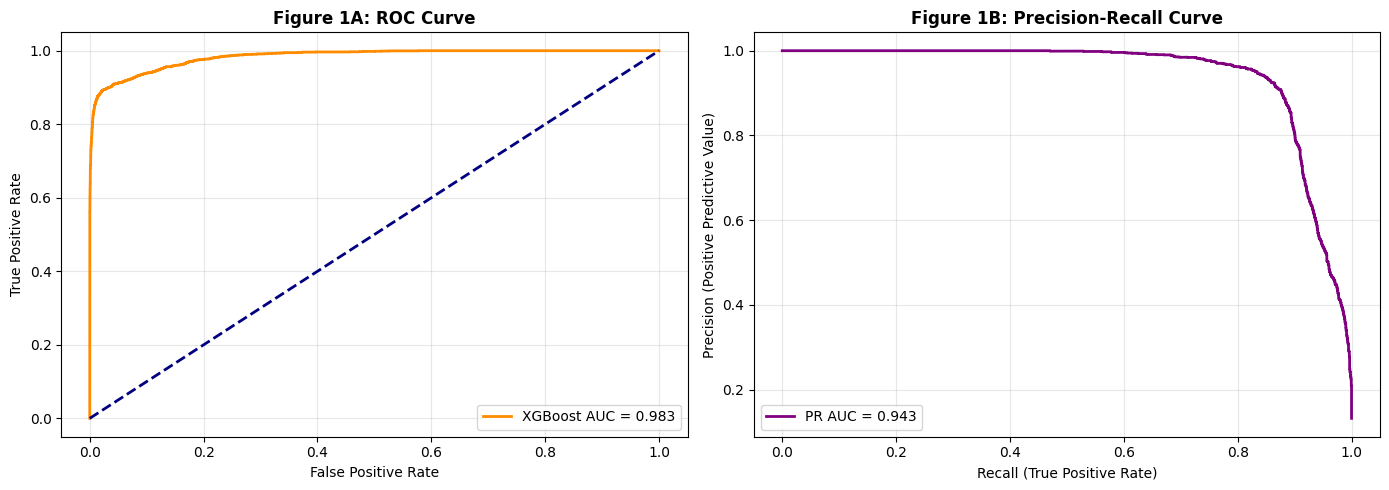

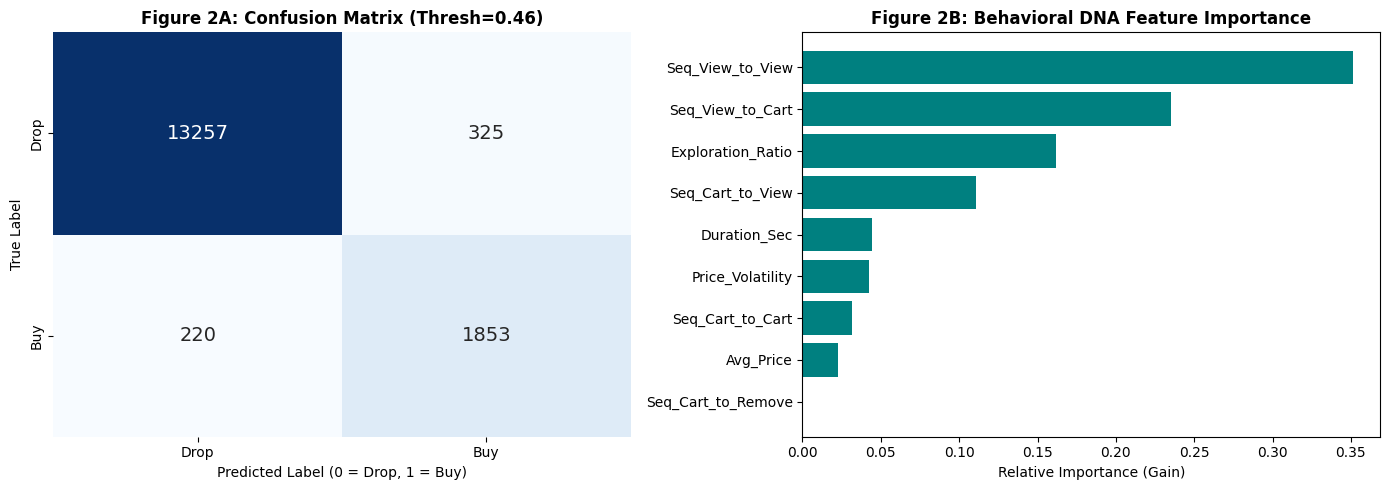

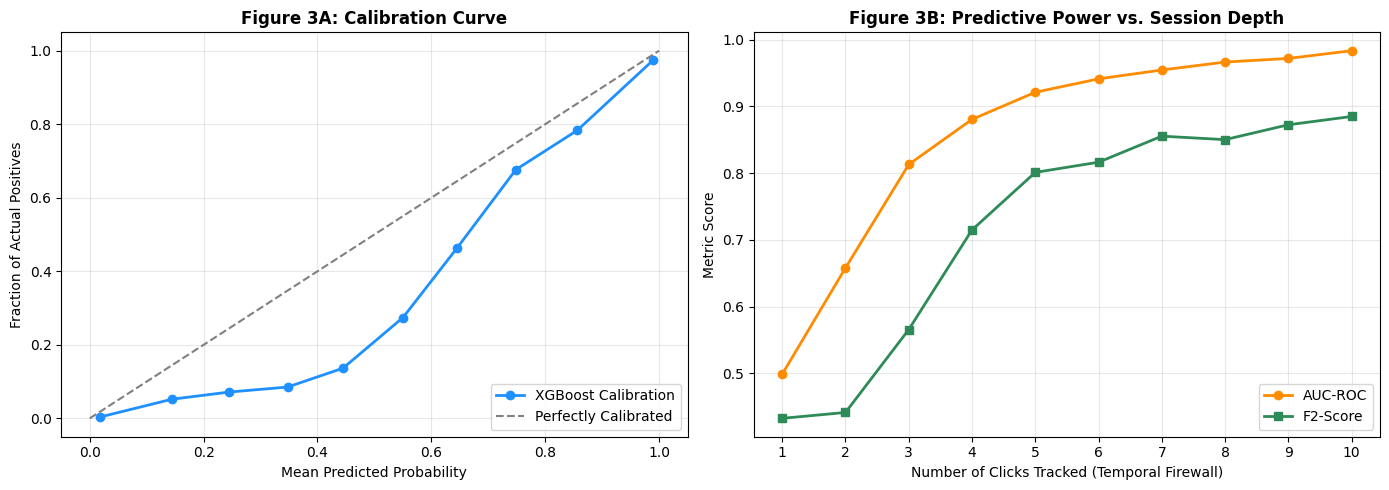

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve, average_precision_score, fbeta_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Step 1: Loading Data (7 Lakh rows)...")
df = pd.read_csv('2019-Nov.csv', usecols=['event_time', 'event_type', 'product_id', 'price', 'user_session'], nrows=700000)
df['event_time'] = pd.to_datetime(df['event_time'])
df = df.sort_values(by=['user_session', 'event_time']).reset_index(drop=True)

print("Step 2: Defining the Target...")
session_outcomes = df.groupby('user_session')['event_type'].apply(
    lambda x: 1 if 'purchase' in x.values else 0
).reset_index()
session_outcomes.rename(columns={'event_type': 'Target_Purchase'}, inplace=True)

print("Step 3: Implementing the Temporal Firewall (First 10 Events)...")
early_events = df.groupby('user_session').head(10).reset_index(drop=True)

event_counts = early_events.groupby('user_session').size()
valid_sessions = event_counts[event_counts >= 3].index
early_events = early_events[early_events['user_session'].isin(valid_sessions)]
session_outcomes = session_outcomes[session_outcomes['user_session'].isin(valid_sessions)]

print("Step 4: BEHAVIORAL DNA FEATURE ENGINEERING (Markov Sequences)...")
def extract_behavioral_dna(group):
    session_duration = (group['event_time'].max() - group['event_time'].min()).total_seconds()
    total_clicks = len(group)
    
    events = group['event_type'].tolist()
    transitions = [f"{events[i]}_to_{events[i+1]}" for i in range(len(events)-1)]
    
    v2v = transitions.count('view_to_view')   
    v2c = transitions.count('view_to_cart')   
    c2v = transitions.count('cart_to_view')   
    c2c = transitions.count('cart_to_cart')   
    c2r = transitions.count('cart_to_remove') 
    
    unique_products = group['product_id'].nunique()
    exploration_ratio = unique_products / total_clicks if total_clicks > 0 else 1.0
    
    prices = group['price'].values
    avg_price = np.mean(prices)
    price_volatility = np.std(prices) if len(prices) > 1 else 0
    
    return pd.Series({
        'Duration_Sec': session_duration,
        'Exploration_Ratio': exploration_ratio,
        'Seq_View_to_View': v2v,
        'Seq_View_to_Cart': v2c,
        'Seq_Cart_to_View': c2v,
        'Seq_Cart_to_Cart': c2c,
        'Seq_Cart_to_Remove': c2r,
        'Avg_Price': avg_price,
        'Price_Volatility': price_volatility
    })

X_features = early_events.groupby('user_session').apply(extract_behavioral_dna).reset_index()
final_df = pd.merge(X_features, session_outcomes, on='user_session')

X = final_df.drop(['user_session', 'Target_Purchase'], axis=1)
y = final_df['Target_Purchase']

print("\nStep 5: Training the Sequence-Aware XGBoost...")
# MODIFIED: We are keeping track of the session IDs for the test set so we can do the click-by-click analysis later!
X_train, X_test, y_train, y_test, session_train, session_test = train_test_split(
    X, y, final_df['user_session'], test_size=0.2, stratify=y, random_state=42
)

imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_m = xgb.XGBClassifier(
    n_estimators=200, 
    max_depth=5, 
    scale_pos_weight=imbalance_ratio * 0.8, 
    gamma=1.5,            
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42, 
    eval_metric='logloss'
)
xgb_m.fit(X_train, y_train)

print("\nStep 6: Final Evaluation & Visualization...")
y_probs = xgb_m.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f2 = 0
for t in np.arange(0.10, 0.90, 0.01): 
    current_preds = (y_probs > t).astype(int)
    current_f2 = fbeta_score(y_test, current_preds, beta=2.0) 
    if current_f2 > best_f2:
        best_f2 = current_f2
        best_threshold = t

y_pred_optimal = (y_probs > best_threshold).astype(int)

print(f"\n--- DNA MODEL PERFORMANCE (Threshold = {best_threshold:.2f}) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_optimal):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_optimal):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_optimal):.3f}")
print(f"F2-Score:  {fbeta_score(y_test, y_pred_optimal, beta=2.0):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_probs):.3f}")


print("\nStep 7: Calculating Click-by-Click Incremental Learning...")
clicks_progression = []
auc_progression = []
f2_progression = []

# Loop through 1 click, 2 clicks... up to 10 clicks to see how the model learns
for k in range(1, 11):
    # Truncate test sessions to exactly 'k' events
    truncated_events = early_events[early_events['user_session'].isin(session_test)].groupby('user_session').head(k)
    
    # Re-extract the DNA features for this limited timeframe
    k_features = truncated_events.groupby('user_session').apply(extract_behavioral_dna).reset_index()
    k_df = pd.merge(k_features, session_outcomes[session_outcomes['user_session'].isin(session_test)], on='user_session')
    
    X_k = k_df.drop(['user_session', 'Target_Purchase'], axis=1)
    y_k = k_df['Target_Purchase']
    
    # Predict and record scores
    y_probs_k = xgb_m.predict_proba(X_k)[:, 1]
    auc_k = roc_auc_score(y_k, y_probs_k)
    f2_k = fbeta_score(y_k, (y_probs_k > best_threshold).astype(int), beta=2.0)
    
    clicks_progression.append(k)
    auc_progression.append(auc_k)
    f2_progression.append(f2_k)

# ========================================================
# COMPREHENSIVE PUBLICATION VISUALIZATIONS
# ========================================================
fig1, ax1 = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_val = roc_auc_score(y_test, y_probs)
ax1[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost AUC = {auc_val:.3f}')
ax1[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1[0].set_title('Figure 1A: ROC Curve', fontweight='bold')
ax1[0].set_xlabel('False Positive Rate')
ax1[0].set_ylabel('True Positive Rate')
ax1[0].legend(loc="lower right")
ax1[0].grid(True, alpha=0.3)

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)
ax1[1].plot(recall, precision, color='purple', lw=2, label=f'PR AUC = {pr_auc:.3f}')
ax1[1].set_title('Figure 1B: Precision-Recall Curve', fontweight='bold')
ax1[1].set_xlabel('Recall (True Positive Rate)')
ax1[1].set_ylabel('Precision (Positive Predictive Value)')
ax1[1].legend(loc="lower left")
ax1[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2[0], cbar=False, annot_kws={"size": 14})
ax2[0].set_title(f'Figure 2A: Confusion Matrix (Thresh={best_threshold:.2f})', fontweight='bold')
ax2[0].set_xlabel('Predicted Label (0 = Drop, 1 = Buy)')
ax2[0].set_ylabel('True Label')
ax2[0].set_xticklabels(['Drop', 'Buy'])
ax2[0].set_yticklabels(['Drop', 'Buy'])

importance = xgb_m.feature_importances_
features = X.columns
indices = np.argsort(importance)
ax2[1].barh(range(len(indices)), importance[indices], color='teal', align='center')
ax2[1].set_yticks(range(len(indices)))
ax2[1].set_yticklabels([features[i] for i in indices])
ax2[1].set_title('Figure 2B: Behavioral DNA Feature Importance', fontweight='bold')
ax2[1].set_xlabel('Relative Importance (Gain)')
plt.tight_layout()
plt.show()

# MODIFIED: Replaced Probability Distribution with Click-by-Click Analysis
fig3, ax3 = plt.subplots(1, 2, figsize=(14, 5))

prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)
ax3[0].plot(prob_pred, prob_true, marker='o', linewidth=2, color='dodgerblue', label='XGBoost Calibration')
ax3[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax3[0].set_title('Figure 3A: Calibration Curve', fontweight='bold')
ax3[0].set_xlabel('Mean Predicted Probability')
ax3[0].set_ylabel('Fraction of Actual Positives')
ax3[0].legend(loc="lower right")
ax3[0].grid(True, alpha=0.3)

ax3[1].plot(clicks_progression, auc_progression, marker='o', linewidth=2, color='darkorange', label='AUC-ROC')
ax3[1].plot(clicks_progression, f2_progression, marker='s', linewidth=2, color='seagreen', label='F2-Score')
ax3[1].set_title('Figure 3B: Predictive Power vs. Session Depth', fontweight='bold')
ax3[1].set_xlabel('Number of Clicks Tracked (Temporal Firewall)')
ax3[1].set_ylabel('Metric Score')
ax3[1].set_xticks(range(1, 11))
ax3[1].legend(loc="lower right")
ax3[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Generating SHAP Representation...


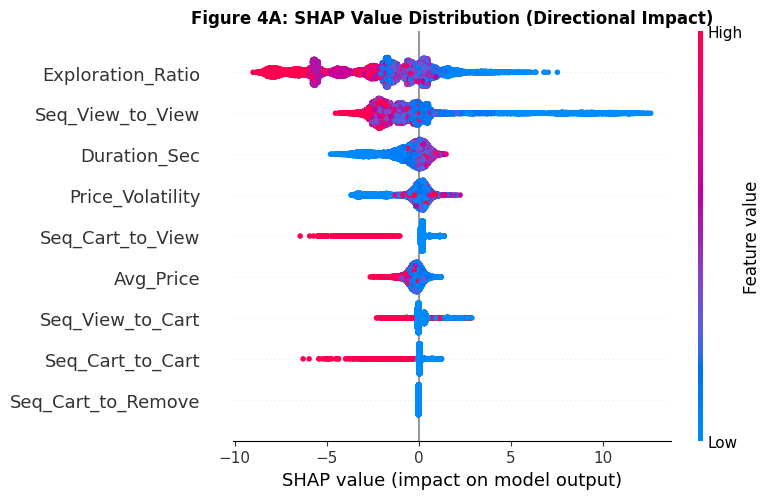

In [4]:
import shap

print("\nGenerating SHAP Representation...")
# Initialize the SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_m)
shap_values = explainer.shap_values(X_test)

# Generate the SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Figure 4A: SHAP Value Distribution (Directional Impact)', fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
def extract_behavioral_dna(group):
    session_duration = (group['event_time'].max() - group['event_time'].min()).total_seconds()
    total_clicks = len(group)
    
    events = group['event_type'].tolist()
    transitions = [f"{events[i]}_to_{events[i+1]}" for i in range(len(events)-1)]
    
    v2v = transitions.count('view_to_view')   
    v2c = transitions.count('view_to_cart')   
    c2v = transitions.count('cart_to_view')   
    c2c = transitions.count('cart_to_cart')   
    c2r = transitions.count('cart_to_remove') 
    v2r = transitions.count('view_to_remove') # <--- ADD THIS LINE
    
    unique_products = group['product_id'].nunique()
    exploration_ratio = unique_products / total_clicks if total_clicks > 0 else 1.0
    
    prices = group['price'].values
    avg_price = np.mean(prices)
    price_volatility = np.std(prices) if len(prices) > 1 else 0
    
    return pd.Series({
        'Duration_Sec': session_duration,
        'Exploration_Ratio': exploration_ratio,
        'Seq_View_to_View': v2v,
        'Seq_View_to_Cart': v2c,
        'Seq_Cart_to_View': c2v,
        'Seq_Cart_to_Cart': c2c,
        'Seq_Cart_to_Remove': c2r,
        'Seq_View_to_Remove': v2r, # <--- ADD THIS LINE
        'Avg_Price': avg_price,
        'Price_Volatility': price_volatility
    })

In [5]:
X_features = early_events.groupby('user_session').apply(extract_behavioral_dna).reset_index()

# --- ADD THIS BLOCK FOR YOUR PRESENTATION TOTALS ---
print("\n--- GLOBAL TRANSITION TOTALS (First 10 Events) ---")
total_c2r = X_features['Seq_Cart_to_Remove'].sum()
total_v2r = X_features['Seq_View_to_Remove'].sum()
total_v2c = X_features['Seq_View_to_Cart'].sum()

print(f"Total 'Cart -> Remove' transitions: {int(total_c2r)}")
print(f"Total 'View -> Remove' transitions: {int(total_v2r)}")
print(f"Total 'View -> Cart' transitions:   {int(total_v2c)}")
print("--------------------------------------------------\n")
# ---------------------------------------------------

final_df = pd.merge(X_features, session_outcomes, on='user_session')


--- GLOBAL TRANSITION TOTALS (First 10 Events) ---
Total 'Cart -> Remove' transitions: 0
Total 'View -> Remove' transitions: 0
Total 'View -> Cart' transitions:   7358
--------------------------------------------------



In [6]:
print("--- DATA DIAGNOSTIC CHECK ---")

# 1. What exact event types actually exist in this dataset?
print("\n1. All Unique Event Types & Their Counts:")
print(df['event_type'].value_counts())

# 2. Does the word 'remove' exist anywhere in the event_type column?
remove_events = df[df['event_type'].str.contains('remove', case=False, na=False)]
print(f"\n2. Total events containing the word 'remove': {len(remove_events)}")

# 3. If there ARE remove events, let's print a real session to see what happened
if len(remove_events) > 0:
    # Get the ID of the very first session that has a remove event
    sample_session_id = remove_events['user_session'].iloc[0]
    
    print(f"\n3. Found one! Here is the timeline for session: {sample_session_id}")
    sample_timeline = df[df['user_session'] == sample_session_id][['event_time', 'event_type', 'product_id']]
    print(sample_timeline)
else:
    print("\n3. CONCLUSION: There are absolutely ZERO remove events in your dataset sample.")
    print("This means calculating 'view_to_remove' is impossible with this specific data.")
print("-----------------------------\n")

--- DATA DIAGNOSTIC CHECK ---

1. All Unique Event Types & Their Counts:
event_type
view        675012
purchase     13643
cart         11345
Name: count, dtype: int64

2. Total events containing the word 'remove': 0

3. CONCLUSION: There are absolutely ZERO remove events in your dataset sample.
This means calculating 'view_to_remove' is impossible with this specific data.
-----------------------------



In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve, average_precision_score, fbeta_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# STEP 1: LOAD & PREP DATA
# ==========================================
print("Step 1: Loading Data (7 Lakh rows)...")
df = pd.read_csv('2019-Nov.csv', usecols=['event_time', 'event_type', 'product_id', 'price', 'user_session'], nrows=700000)
df['event_time'] = pd.to_datetime(df['event_time'])
df = df.sort_values(by=['user_session', 'event_time']).reset_index(drop=True)

# ==========================================
# STEP 2: DEFINE TARGET
# ==========================================
print("Step 2: Defining the Target...")
session_outcomes = df.groupby('user_session')['event_type'].apply(
    lambda x: 1 if 'purchase' in x.values else 0
).reset_index()
session_outcomes.rename(columns={'event_type': 'Target_Purchase'}, inplace=True)

# ==========================================
# STEP 3: TEMPORAL FIREWALL (Early Prediction)
# ==========================================
print("Step 3: Implementing the Temporal Firewall (First 10 Events)...")
early_events = df.groupby('user_session').head(10).reset_index(drop=True)

event_counts = early_events.groupby('user_session').size()
valid_sessions = event_counts[event_counts >= 3].index
early_events = early_events[early_events['user_session'].isin(valid_sessions)]
session_outcomes = session_outcomes[session_outcomes['user_session'].isin(valid_sessions)]

# ==========================================
# STEP 4: BEHAVIORAL DNA EXTRACTION (Cleaned)
# ==========================================
print("Step 4: BEHAVIORAL DNA FEATURE ENGINEERING (Markov Sequences)...")
def extract_behavioral_dna(group):
    session_duration = (group['event_time'].max() - group['event_time'].min()).total_seconds()
    total_clicks = len(group)
    
    events = group['event_type'].tolist()
    transitions = [f"{events[i]}_to_{events[i+1]}" for i in range(len(events)-1)]
    
    # Track only valid transitions
    v2v = transitions.count('view_to_view')   
    v2c = transitions.count('view_to_cart')   
    c2v = transitions.count('cart_to_view')   
    c2c = transitions.count('cart_to_cart')   
    
    unique_products = group['product_id'].nunique()
    exploration_ratio = unique_products / total_clicks if total_clicks > 0 else 1.0
    
    prices = group['price'].values
    avg_price = np.mean(prices)
    price_volatility = np.std(prices) if len(prices) > 1 else 0
    
    return pd.Series({
        'Duration_Sec': session_duration,
        'Exploration_Ratio': exploration_ratio,
        'Seq_View_to_View': v2v,
        'Seq_View_to_Cart': v2c,
        'Seq_Cart_to_View': c2v,
        'Seq_Cart_to_Cart': c2c,
        'Avg_Price': avg_price,
        'Price_Volatility': price_volatility
    })

X_features = early_events.groupby('user_session').apply(extract_behavioral_dna).reset_index()

# --- PRESENTATION TOTALS ---
print("\n--- GLOBAL TRANSITION TOTALS (First 10 Events) ---")
print(f"Total 'View -> View' transitions: {int(X_features['Seq_View_to_View'].sum())}")
print(f"Total 'View -> Cart' transitions: {int(X_features['Seq_View_to_Cart'].sum())}")
print(f"Total 'Cart -> View' transitions: {int(X_features['Seq_Cart_to_View'].sum())}")
print(f"Total 'Cart -> Cart' transitions: {int(X_features['Seq_Cart_to_Cart'].sum())}")
print("--------------------------------------------------\n")

final_df = pd.merge(X_features, session_outcomes, on='user_session')

X = final_df.drop(['user_session', 'Target_Purchase'], axis=1)
y = final_df['Target_Purchase']

# ==========================================
# STEP 5: TRAIN / TEST SPLIT
# ==========================================
print("Step 5: Training the Sequence-Aware XGBoost...")
X_train, X_test, y_train, y_test, session_train, session_test = train_test_split(
    X, y, final_df['user_session'], test_size=0.2, stratify=y, random_state=42
)

# ==========================================
# STEP 6: MODEL TRAINING (XGBoost)
# ==========================================
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_m = xgb.XGBClassifier(
    n_estimators=200, 
    max_depth=5, 
    scale_pos_weight=imbalance_ratio * 0.8, 
    gamma=1.5,            
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42, 
    eval_metric='logloss'
)
xgb_m.fit(X_train, y_train)

# ==========================================
# STEP 7: EVALUATION & OPTIMIZATION
# ==========================================
print("\nStep 6: Final Evaluation & Visualization...")
y_probs = xgb_m.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f2 = 0
for t in np.arange(0.10, 0.90, 0.01): 
    current_preds = (y_probs > t).astype(int)
    current_f2 = fbeta_score(y_test, current_preds, beta=2.0) 
    if current_f2 > best_f2:
        best_f2 = current_f2
        best_threshold = t

y_pred_optimal = (y_probs > best_threshold).astype(int)

print(f"\n--- DNA MODEL PERFORMANCE (Threshold = {best_threshold:.2f}) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_optimal):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_optimal):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_optimal):.3f}")
print(f"F2-Score:  {fbeta_score(y_test, y_pred_optimal, beta=2.0):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_probs):.3f}")

# ==========================================
# STEP 8: CLICK-BY-CLICK ANALYSIS
# ==========================================
print("\nStep 7: Calculating Click-by-Click Incremental Learning...")
clicks_progression = []
auc_progression = []
f2_progression = []

for k in range(1, 11):
    # Truncate test sessions to exactly 'k' events
    truncated_events = early_events[early_events['user_session'].isin(session_test)].groupby('user_session').head(k)
    
    # Re-extract the DNA features
    k_features = truncated_events.groupby('user_session').apply(extract_behavioral_dna).reset_index()
    k_df = pd.merge(k_features, session_outcomes[session_outcomes['user_session'].isin(session_test)], on='user_session')
    
    X_k = k_df.drop(['user_session', 'Target_Purchase'], axis=1)
    y_k = k_df['Target_Purchase']
    
    y_probs_k = xgb_m.predict_proba(X_k)[:, 1]
    auc_k = roc_auc_score(y_k, y_probs_k)
    f2_k = fbeta_score(y_k, (y_probs_k > best_threshold).astype(int), beta=2.0)
    
    clicks_progression.append(k)
    auc_progression.append(auc_k)
    f2_progression.append(f2_k)

# ==========================================
# STEP 9: PUBLICATION VISUALIZATIONS
# ==========================================
print("\nGenerating Visualizations...")
plt.style.use('seaborn-v0_8-whitegrid')

# Figure 1: ROC and PR Curves
fig1, ax1 = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_val = roc_auc_score(y_test, y_probs)
ax1[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost AUC = {auc_val:.3f}')
ax1[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1[0].set_title('Figure 1A: ROC Curve', fontweight='bold')
ax1[0].set_xlabel('False Positive Rate')
ax1[0].set_ylabel('True Positive Rate')
ax1[0].legend(loc="lower right")

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)
ax1[1].plot(recall, precision, color='purple', lw=2, label=f'PR AUC = {pr_auc:.3f}')
ax1[1].set_title('Figure 1B: Precision-Recall Curve', fontweight='bold')
ax1[1].set_xlabel('Recall (True Positive Rate)')
ax1[1].set_ylabel('Precision (Positive Predictive Value)')
ax1[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

# Figure 2: Confusion Matrix and Feature Importance
fig2, ax2 = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2[0], cbar=False, annot_kws={"size": 14})
ax2[0].set_title(f'Figure 2A: Confusion Matrix (Thresh={best_threshold:.2f})', fontweight='bold')
ax2[0].set_xlabel('Predicted Label (0 = Drop, 1 = Buy)')
ax2[0].set_ylabel('True Label')
ax2[0].set_xticklabels(['Drop', 'Buy'])
ax2[0].set_yticklabels(['Drop', 'Buy'])

importance = xgb_m.feature_importances_
features = X.columns
indices = np.argsort(importance)
ax2[1].barh(range(len(indices)), importance[indices], color='teal', align='center')
ax2[1].set_yticks(range(len(indices)))
ax2[1].set_yticklabels([features[i] for i in indices])
ax2[1].set_title('Figure 2B: Behavioral DNA Feature Importance', fontweight='bold')
ax2[1].set_xlabel('Relative Importance (Gain)')
plt.tight_layout()
plt.show()

# Figure 3: Calibration and Session Depth
fig3, ax3 = plt.subplots(1, 2, figsize=(14, 5))
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)
ax3[0].plot(prob_pred, prob_true, marker='o', linewidth=2, color='dodgerblue', label='XGBoost Calibration')
ax3[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax3[0].set_title('Figure 3A: Calibration Curve', fontweight='bold')
ax3[0].set_xlabel('Mean Predicted Probability')
ax3[0].set_ylabel('Fraction of Actual Positives')
ax3[0].legend(loc="lower right")

ax3[1].plot(clicks_progression, auc_progression, marker='o', linewidth=2, color='darkorange', label='AUC-ROC')
ax3[1].plot(clicks_progression, f2_progression, marker='s', linewidth=2, color='seagreen', label='F2-Score')
ax3[1].set_title('Figure 3B: Predictive Power vs. Session Depth', fontweight='bold')
ax3[1].set_xlabel('Number of Clicks Tracked (Temporal Firewall)')
ax3[1].set_ylabel('Metric Score')
ax3[1].set_xticks(range(1, 11))
ax3[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Step 1: Loading Data (7 Lakh rows)...
Step 2: Defining the Target...
Step 3: Implementing the Temporal Firewall (First 10 Events)...
Step 4: BEHAVIORAL DNA FEATURE ENGINEERING (Markov Sequences)...

--- GLOBAL TRANSITION TOTALS (First 10 Events) ---
Total 'View -> View' transitions: 353628
Total 'View -> Cart' transitions: 7358
Total 'Cart -> View' transitions: 2584
Total 'Cart -> Cart' transitions: 2036
--------------------------------------------------

Step 5: Training the Sequence-Aware XGBoost...

Step 6: Final Evaluation & Visualization...

--- DNA MODEL PERFORMANCE (Threshold = 0.47) ---
Accuracy:  0.964
Precision: 0.857
Recall:    0.878
F1-Score:  0.867
F2-Score:  0.874
AUC-ROC:   0.981

Step 7: Calculating Click-by-Click Incremental Learning...
